In [ ]:
import torch
x=torch.tensor(1.0)
y=torch.tensor(2.0)
z=3*x**2+4*y**2-5*x*y
print(z)

tensor(9.)


In [ ]:
x=torch.tensor(1.0, requires_grad=True)
y=torch.tensor(2.0, requires_grad=True)
z=3*x**2+4*y**2-5*x*y
print(z)
z.backward()

print(x.grad, y.grad)

tensor(9., grad_fn=<SubBackward0>)
tensor(-4.) tensor(11.)


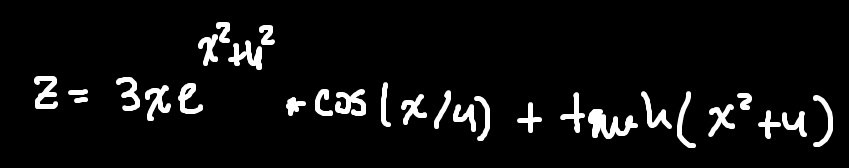

In [ ]:
x=torch.tensor(1.0, requires_grad=True)
y=torch.tensor(2.0, requires_grad=False)
z=3*x*torch.exp(x**2+y**2)*torch.cos(x/y)+torch.tanh(x**2+y)
print(z)
z.backward()

print(x.grad, y.grad)

tensor(391.7295, grad_fn=<AddBackward0>)
tensor(1065.4933) None


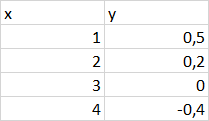

tensor(-0.1831, requires_grad=True) tensor(0.6115, requires_grad=True)


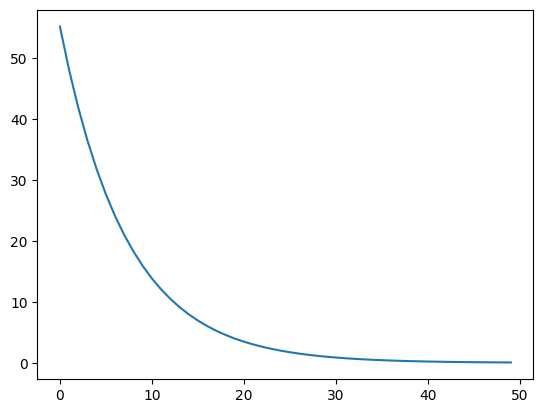

In [ ]:
# i) datos de entrenamiento
x=torch.tensor([1,2,3,4])
y=torch.tensor([0.5, 0.2, 0.0, -0.4])

# ii) Parámetros del modelo
m=torch.tensor(1.0, requires_grad=True)
b=torch.tensor(1.0, requires_grad=True)
e=[]
alpha=torch.tensor(0.001)
for i in range(50):
  m.grad=None
  b.grad=None
  # ii) Uso del modelo, en este caso el modelo es y=m*x+b
  y_est=m*x+b

  # iii) Función de error, calculando manualmente un MSE
  error=torch.sum((y_est-y)**2)
  e.append(error.item())
  error.backward()

  # iv) Optimizador que modifica las variables
  with torch.no_grad():
    m-=alpha*m.grad
    b-=alpha*b.grad

import matplotlib.pyplot as plt
plt.plot(e)

print(m,b)